In [1]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis, raw_scores
from hbn.visualization import utils as utils
from hbn.data import data_utils

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [2]:
vis.plotting_style()

In [3]:
## visualize functions

# FUNCTIONS
def plot_bar(df, x='features', hue=None, plot_null=True, ax=None):

    # plot data
    data = df[df['data']=='data']
    fig = vis.barplot(
                data=data, 
                y='roc_auc_score', 
                x=x, 
                ylabel='ROC AUC', 
                hue=hue,
                xlabel=None, 
                ylim=[.4, 1.05],
                # join_lines=False,
                # markers="D",
                # scale=0.6,
                figsize=(6,4),
                ax=ax
                )

    # plot null model
    if plot_null:
        null = df[df['data']=='null'].groupby(x)['roc_auc_score'].mean().values
        plt.axhline(y=null.mean(), color='k', linestyle='--')

    return fig

def plot_line(df, x='readers', hue=None, plot_null=True, ax=None):
    fig = vis.pointplot(
                data=df[df['data']=='data'].sort_values(by=['features'], ascending=False), 
                y='roc_auc_score', 
                x=x, 
                ylabel='ROC AUC', 
                hue=hue,
                xlabel=None, 
                ylim=[.4, 1.05],
                # join_lines=False,
                # markers="D",
                # scale=0.6,
                figsize=(6,4),
                ax=ax
                )

    # plot null model
    if plot_null:
        null = df[df['data']=='null'].groupby(x)['roc_auc_score'].mean().values
        plt.axhline(y=null.mean(), color='k', linestyle='--')

    return fig

## Load Model Results

In [4]:

# load data for all models run in `model_parent`
summary, features = data_utils.load_model_results(model='reading_augustC')

summary['DX'] = summary['DX_Reading'].map({
    'reading_all_comorbidities_No Diagnosis Given': 'reading (all combord.)',
    'reading_no_comorbidities_No Diagnosis Given': 'reading (no combord.)',
    'adhd_no_reading_No Diagnosis Given': 'adhd only',
    })

summary['Gender'] = summary['DX_Reading'].map({
    'reading_all_comorbidities': 'reading (all combord.)',
    'reading_no_comorbidities': 'reading (no combord.)',    
    })

summary['features'] = summary['features'].str.replace('Child-', '').str.replace('Parent-', '')

In [5]:
summary['features'].unique()

array(['executive-function', 'production', 'reading-minimal', 'language',
       'phonological', 'reading-all', 'intelligence', 'all-demos',
       'emotional-status', 'reading', 'teacher-externalizing',
       'child-internalizing', 'child-externalizing',
       'parent-externalizing', 'teacher-internalizing',
       'parent-internalizing', 'phonological-minimal'], dtype=object)

In [32]:
## FUNCTIONS

def fig1A(ax, subplot='A', feature='selected_all'):

    features = ['language', 'executive-function', 
            'emotional-status',  'production', 
            'phonological', 'reading']

    default_params = {'Sex': ['male_female'],
                    'feature_threshold': [f'{feature}',],
                    'DX': ['reading (all combord.)'],
                    'readers': ['all'],
                    'data': ['data'],
                    'features': features,
                    'Race': ['all'],
                    }

    # filter dataframe
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot data
    vis.barplot(data=df_filter, x='features', ax=ax, subplot=subplot)

    default_params.update({'data': ['null']})

    # filter dataframe to just 1 feature
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot reading model
    ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

    default_params.update({'data': ['data'], 'features': ['reading-minimal'],})

    # filter dataframe to just 1 feature
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot reading model
    ax.axhline(y=df_filter['roc_auc_score'].mean(), color='grey', linestyle='dotted')

def fig1B(ax, subplot='B', feature='all'):
    
        default_params = {'Sex': ['male_female'],
                        'readers': ['early', 'emerging', 'expert'],
                        'feature_threshold': [f'{feature}'],
                        'DX': ['reading (all combord.)'],
                        'data': ['data'],
                        'features': ['reading-minimal', 'phonological',],
                        'Race': ['all'],
                        }

        # filter dataframe
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        vis.pointplot(data=df_filter.sort_values(by=['readers']), x='readers', hue='features', ax=ax, subplot=subplot)

        default_params.update({'data': ['null']})

        # filter dataframe to just 1 feature
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot reading model
        ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

def fig1C(ax, subplot='C', feature='all'):
    
        default_params = {'Sex': ['male', 'female'],
                        'readers': ['all'],
                        'feature_threshold': [f'{feature}'],
                        'DX': ['reading (all combord.)'],
                        'data': ['data'],
                        'features':  ['reading-minimal', 'phonological',],
                        'Race': ['all'],
                        }

        # filter dataframe
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        vis.barplot(data=df_filter.sort_values(by=['Sex']), x='Sex', hue='features', ax=ax, subplot=subplot, legend=False)

        default_params.update({'data': ['null']})

        # filter dataframe to just 1 feature
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot reading model
        ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')


def fig1D(ax, subplot='D', feature='all'):
    
        default_params = {'Sex': ['male_female'],
                        'readers': ['all'],
                        'feature_threshold': [f'{feature}'],
                        'DX': ['reading (all combord.)', 'reading (no combord.)', 'adhd only'],
                        'data': ['data'],
                        'features': ['reading-minimal', 'phonological',],
                        'Race': ['all'],
                        }

        # filter dataframe
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        vis.barplot(data=df_filter.sort_values(by=['features']), x='DX', 
                    hue='features', ax=ax, subplot=subplot, legend=False,)

        default_params.update({'data': ['null']})

        # filter dataframe to just 1 feature
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot reading model
        ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

## Fig. 1

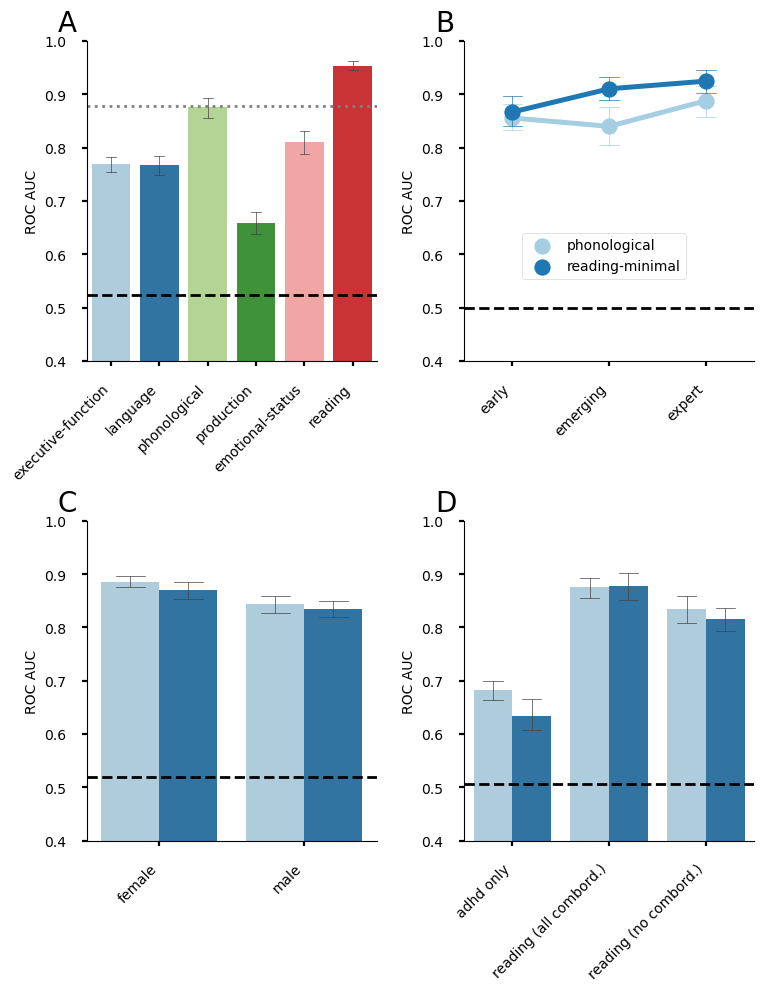

In [26]:

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(1,4))
gs = GridSpec(2, 2, figure=fig)

# 1A
ax = fig.add_subplot(gs[0, 0])
fig1A(ax, feature='selected_all')

# 1B
ax = fig.add_subplot(gs[0, 1])
fig1B(ax, feature='selected_all')

# # 1C
ax = fig.add_subplot(gs[1, 0])
fig1C(ax, feature='selected_all')

# 1D
ax = fig.add_subplot(gs[1, 1])
fig1D(ax, feature='selected_all')

fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.3, hspace=.5)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'fig1.png'), bbox_inches='tight')

### Fig 1. Alt

In [21]:
## FUNCTIONS

def fig1Aalt(ax, subplot='A'):

    features = ['language', 'executive-function', 
            'emotional-status',  'production', 
            'phonological', 'reading']

    default_params = {'Sex': ['male_female'],
                    'feature_threshold': ['selected_all', 'top_5_selected_features'],
                    'DX': ['reading (all combord.)', ],
                    'readers': ['all'],
                    'data': ['data'],
                    'features': features,
                    'Race': ['all'],
                    }

    # filter dataframe
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot data
    vis.barplot(data=df_filter, x='features', hue='feature_threshold', ax=ax, subplot=subplot)

    default_params.update({'data': ['null']})

    # filter dataframe to just 1 feature
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot reading model
    ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

    default_params.update({'data': ['data'], 'features': ['reading-minimal'],})

    # filter dataframe to just 1 feature
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot reading model
    ax.axhline(y=df_filter['roc_auc_score'].mean(), color='grey', linestyle='dotted')

def fig1Balt(ax, subplot='B'):
    
        default_params = {'Sex': ['male_female'],
                        'readers': ['early', 'emerging', 'expert'],
                        'feature_threshold': ['selected_all'],
                        'DX': ['reading (all combord.)'],
                        'data': ['data'],
                        'features': ['reading', 'reading-minimal',],
                        'Race': ['all'],
                        }

        # filter dataframe
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        vis.pointplot(data=df_filter.sort_values(by=['readers']), x='readers', hue='features', ax=ax, subplot=subplot)

        default_params.update({'data': ['null']})

        # filter dataframe to just 1 feature
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot reading model
        ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

def fig1Calt(ax, subplot='C'):
    
        default_params = {'Sex': ['male', 'female'],
                        'readers': ['all'],
                        'feature_threshold': ['selected_all'],
                        'DX': ['reading (all combord.)'],
                        'data': ['data'],
                        'features':  ['reading', 'reading-minimal'],
                        'Race': ['all'],
                        }

        # filter dataframe
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        vis.barplot(data=df_filter.sort_values(by=['Sex']), x='Sex', hue='features', ax=ax, subplot=subplot, legend=False)

        default_params.update({'data': ['null']})

        # filter dataframe to just 1 feature
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot reading model
        ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')


def fig1Dalt(ax, subplot='D'):
    
        default_params = {'Sex': ['male_female'],
                        'readers': ['all'],
                        'feature_threshold': ['selected_all'],
                        'DX': ['reading (all combord.)', 'reading (no combord.)', 'adhd only'],
                        'data': ['data'],
                        'features': ['reading-minimal', 'reading',],
                        'Race': ['all'],
                        }

        # filter dataframe
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        vis.barplot(data=df_filter.sort_values(by=['features']), x='DX', 
                    hue='features', ax=ax, subplot=subplot, legend=False,)

        default_params.update({'data': ['null']})

        # filter dataframe to just 1 feature
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot reading model
        ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

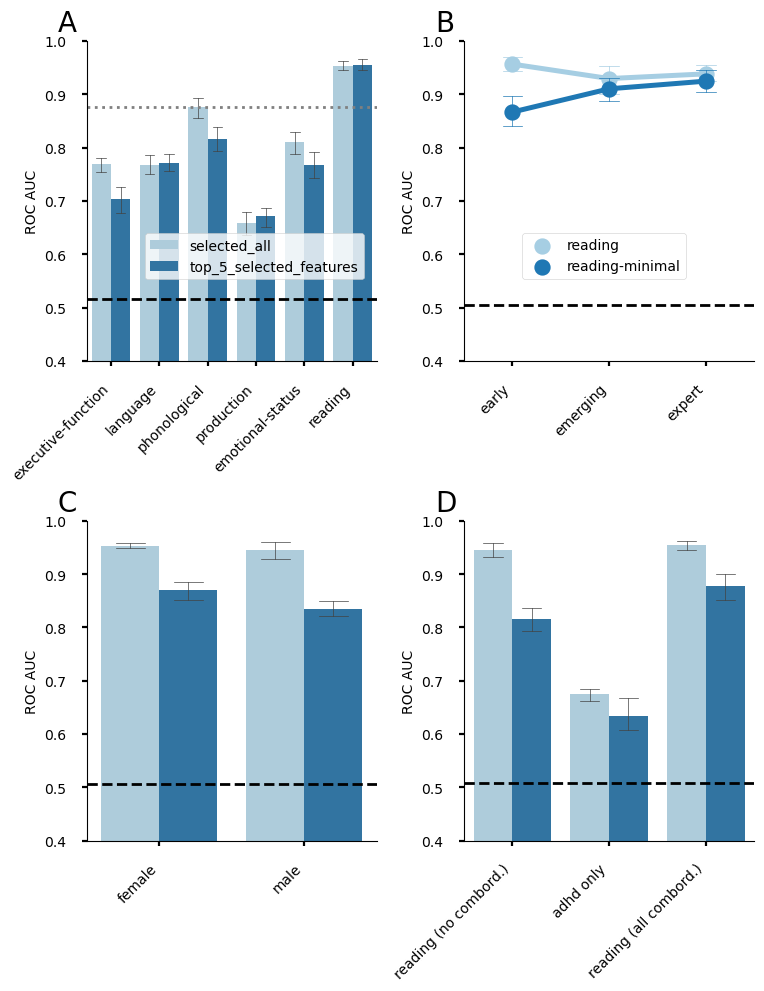

In [22]:

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(1,4))
gs = GridSpec(2, 2, figure=fig)

# 1A
ax = fig.add_subplot(gs[0, 0])
fig1Aalt(ax,)

# 1B
ax = fig.add_subplot(gs[0, 1])
fig1Balt(ax,)

# # 1C
ax = fig.add_subplot(gs[1, 0])
fig1Calt(ax,)

# 1D
ax = fig.add_subplot(gs[1, 1])
fig1Dalt(ax,)

fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.3, hspace=.5)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'fig1-alt.png'), bbox_inches='tight')

In [10]:


def fig2A(ax, subplot='A'):

    features = ['reading-minimal',]

    default_params = {'Sex': ['male_female'],
                    'feature_threshold': ['selected_all'],
                    'DX': ['reading (all combord.)', 'reading (no combord.)'],
                    'readers': ['all'],
                    'data': ['data'],
                    'features': features,
                    'Race': ['Black/African American', 'White/Caucasian'],
                    }

    # filter dataframe
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot data
    vis.barplot(data=df_filter, x='DX', hue='Race', ax=ax, subplot=subplot, legend=False, title='Reading-Minimal')

    default_params.update({'data': ['null']})

    # filter dataframe to just 1 feature
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot reading model
    ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

def fig2B(ax, subplot='B'):

    features = ['phonological']

    default_params = {'Sex': ['male_female'],
                    'feature_threshold': ['selected_all'],
                    'DX': ['reading (all combord.)', 'reading (no combord.)'],
                    'readers': ['all'],
                    'data': ['data'],
                    'features': features,
                    'Race': ['Black/African American', 'White/Caucasian'],
                    }

    # filter dataframe
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot data
    vis.barplot(data=df_filter, x='DX', hue='Race', ax=ax, subplot=subplot, title=features[0])

    default_params.update({'data': ['null']})

    # filter dataframe to just 1 feature
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot reading model
    ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

### Fig. 2

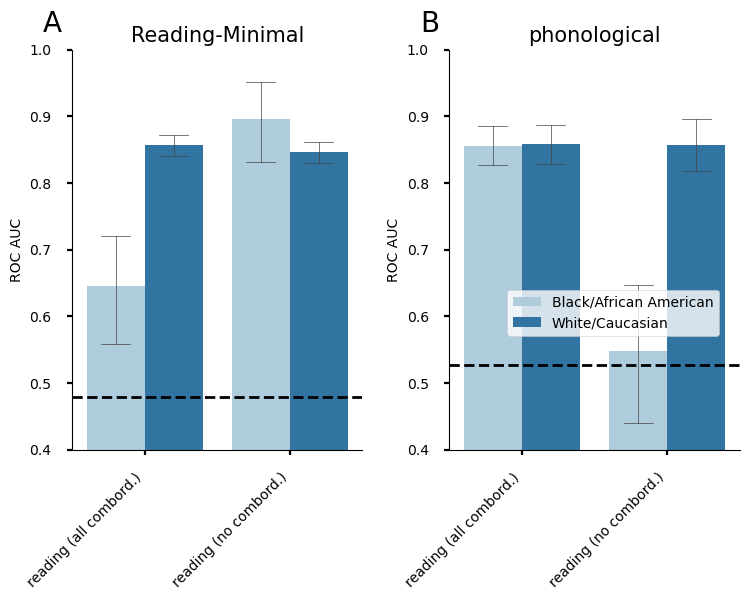

In [11]:

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(1,2))
gs = GridSpec(1, 2, figure=fig)

# 2A
ax = fig.add_subplot(gs[0, 0])
fig2A(ax)

# 2C
ax = fig.add_subplot(gs[0, 1])
fig2B(ax)

fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.3, hspace=.5)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'fig2.png'), bbox_inches='tight')

In [12]:
def fig3A(ax, subplot='A', model='all'):

    features = ['language', 'phonological',
            'emotional-status',  'production', 'reading-minimal']


    default_params = {'Sex': ['male_female'],
                    'feature_threshold': ['selected_all'],
                    'Gender': [f'reading ({model} combord.)', ],
                    'DX': [np.float("NaN")],
                    'readers': ['all'],
                    'data': ['data'],
                    'features': features,
                    'Race': ['all'],
                    }

    # filter dataframe
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot data
    vis.barplot(data=df_filter, x='features',  ax=ax, subplot=subplot)

    default_params.update({'data': ['null']})

    # filter dataframe to just 1 feature
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot reading model
    ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

def fig3B(ax, subplot='B', model='all'):

    features = ['parent-internalizing', 'parent-externalizing',
                'child-internalizing', 'child-externalizing',
                'teacher-internalizing', 'teacher-externalizing']


    default_params = {'Sex': ['male_female'],
                    'feature_threshold': ['selected_all'],
                    'Gender': [f'reading ({model} combord.)'],
                    'DX': [np.float("NaN")],
                    'readers': ['all'],
                    'data': ['data'],
                    'features': features,
                    'Race': ['all'],
                    }

    # filter dataframe
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # get new cols
    df_filter['int_ext'] = df_filter['features'].str.extract('(externalizing|internalizing)')
    df_filter['assessment'] = df_filter['features'].str.extract('(teacher|child|parent)')

    # plot data
    vis.barplot(data=df_filter, x='int_ext', hue='assessment', ax=ax, subplot=subplot)

    default_params.update({'data': ['null']})

    # filter dataframe to just 1 feature
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot reading model
    ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

def fig3C(ax, subplot='C', model='all'):

    features = ['parent-internalizing', 'parent-externalizing',]


    default_params = {'Sex': ['male_female'],
                    'feature_threshold': ['selected_all'],
                    'Gender': [f'reading ({model} combord.)'],
                    'DX': [np.float("NaN")],
                    'readers': ['early', 'emerging', 'expert'],
                    'data': ['data'],
                    'features': features,
                    'Race': ['all'],
                    }

    # filter dataframe
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # get new cols
    df_filter['int_ext'] = df_filter['features'].str.extract('(externalizing|internalizing)')
    df_filter['assessment'] = df_filter['features'].str.extract('(teacher|child|parent)')

    # plot data
    vis.pointplot(data=df_filter.sort_values(by='readers'), x='readers', hue='int_ext', ax=ax, subplot=subplot,)

    default_params.update({'data': ['null']})

    # filter dataframe to just 1 feature
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot reading model
    ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

def fig3D(ax, subplot='D', model='all'):

    features = ['parent-internalizing', 'parent-externalizing',]


    default_params = {'Sex': ['male_female'],
                    'feature_threshold': ['selected_all'],
                    'Gender': [f'reading ({model} combord.)'],
                    'DX': [np.float("NaN")],
                    'readers': ['all'],
                    'data': ['data'],
                    'features': features,
                    'Race': ['Black/African American', 'White/Caucasian'],
                    }

    # filter dataframe
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # get new cols
    df_filter['int_ext'] = df_filter['features'].str.extract('(externalizing|internalizing)')
    df_filter['assessment'] = df_filter['features'].str.extract('(teacher|child|parent)')

    # plot data
    vis.barplot(data=df_filter.sort_values(by='int_ext'), x='Race', hue='int_ext', ax=ax, subplot=subplot, legend=False)

    default_params.update({'data': ['null']})

    # filter dataframe to just 1 feature
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # plot reading model
    ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

def fig3B_2(ax):
    features = ['parent-internalizing', 'parent-externalizing',]


    default_params = {'Sex': ['male_female'],
                    'feature_threshold': ['selected_all'],
                    'Gender': [f'reading (no combord.)'],
                    'DX': [np.float("NaN")],
                    'readers': ['all'],
                    'data': ['data'],
                    'features': features,
                    'Race': ['all'],
                    }

    # filter dataframe
    df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

    # get new cols
    df_filter['int_ext'] = df_filter['features'].str.extract('(externalizing|internalizing)')
    df_filter['assessment'] = df_filter['features'].str.extract('(teacher|child|parent)')

    # plot data
    vis.pointplot(data=df_filter, x='int_ext', ax=ax, legend=False, marker_color=['Grey'])

### Fig 3

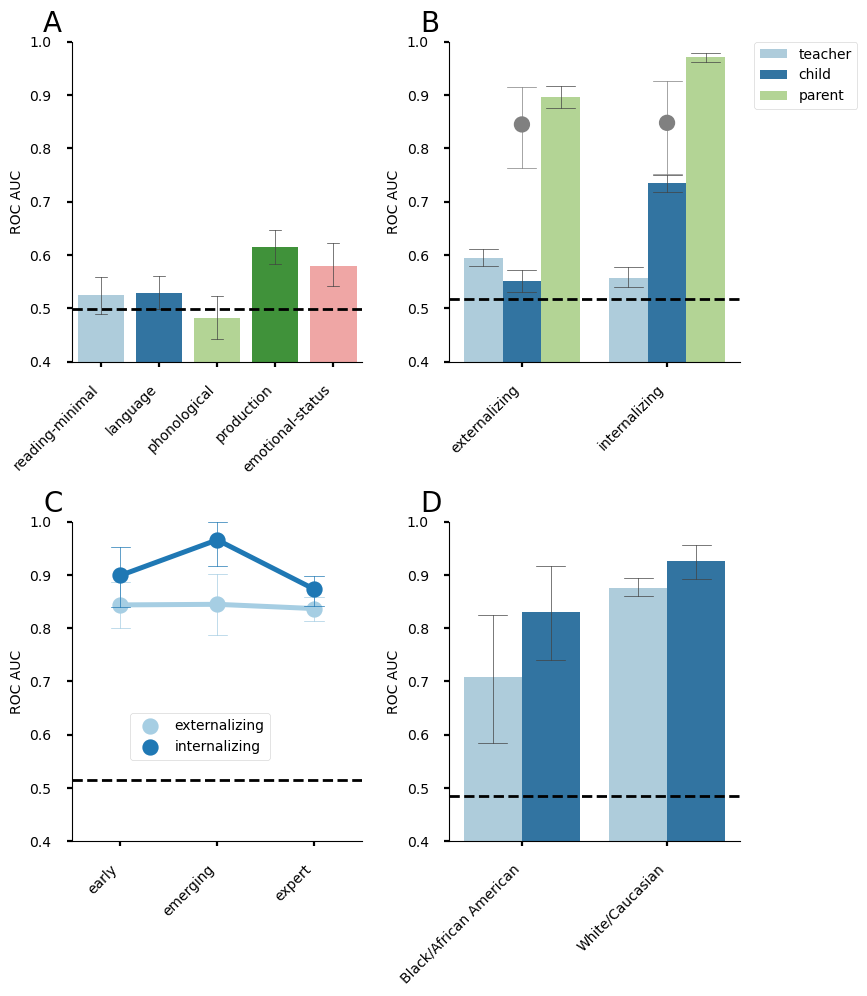

In [154]:

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(1,4))
gs = GridSpec(2, 2, figure=fig)

# 3A
ax = fig.add_subplot(gs[0, 0])
fig3A(ax, model='all')

# 3B
ax = fig.add_subplot(gs[0, 1])
fig3B_2(ax)
fig3B(ax, model='all')

# 3C
ax = fig.add_subplot(gs[1, 0])
fig3C(ax, model='all')

# 3D
ax = fig.add_subplot(gs[1, 1])
fig3D(ax, model='all')

fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.3, hspace=.5)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'fig3.png'), bbox_inches='tight')

### Supp. 1

In [25]:
# df = pd.read_csv(os.path.join(Defaults.INTERIM_FEATURES_DIR, 'participant_train_test.csv'))


df['DX_ADHD'].unique()

array(['No Diagnosis Given', 'adhd_all_comorbidities', 'other_diagnoses',
       'adhd_no_comorbidities'], dtype=object)

### Supp Fig. 2

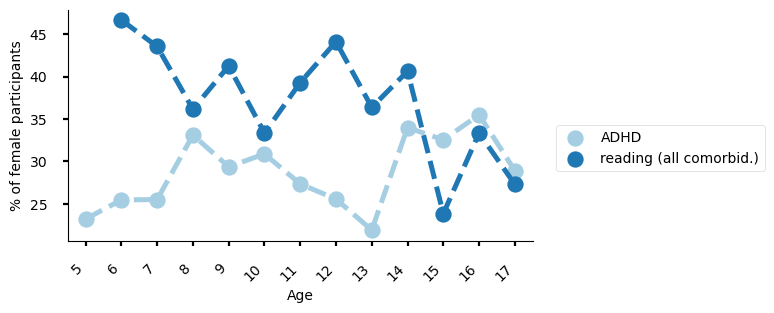

In [193]:

def Supp1(ax):
  # load data
  df = pd.read_csv(os.path.join(Defaults.INTERIM_FEATURES_DIR, 'participant_train_test.csv'))
  df.rename(columns={'PreInt_Demos_Fam,Child_Race_cat':'Race'}, inplace=True)
  
  # filter data
  df1 = df.loc[df['Age_round']<=17].groupby('Identifiers').first().reset_index()
  df1['DX_Reading'] = df1['DX_Reading'].map({'reading_all_comorbidities': 'reading (all comorbid.)', 
                                             'adhd_no_reading': 'ADHD',
                                             'reading_no_comorbidities': 'reading (no comorbid.)'
                                             })
  df1['Age_round'] = df1['Age_round'].astype('int')

  # calculate female percentage
  df_filter = raw_scores.calculate_sex_percentage(df1, groupby_cols=['Age_round', 'DX_Reading'])

  # plot female percentage across age and diagnosis
  data = df_filter[(df_filter['DX_Reading'].isin(['reading (all comorbid.)', 'ADHD']))
                    & (df_filter['split']=='train')]

  sns.pointplot(x='Age_round', y='female_percentage', data=data, hue='DX_Reading', linestyles='--')
  plt.xticks(rotation=45, ha='right'); 

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(6,3))
gs = GridSpec(1, 1, figure=fig)

# 3A
ax = fig.add_subplot(gs[0, 0])
Supp1(ax)
ax.legend(bbox_to_anchor=(1.05, .5), loc=2, borderaxespad=0.0)
ax.set_ylabel('% of female participants')
ax.set_xlabel('Age');

fig.savefig(os.path.join(Defaults.FIG_DIR, f'Supp2.png'), bbox_inches='tight')



### Supp. Fig 3

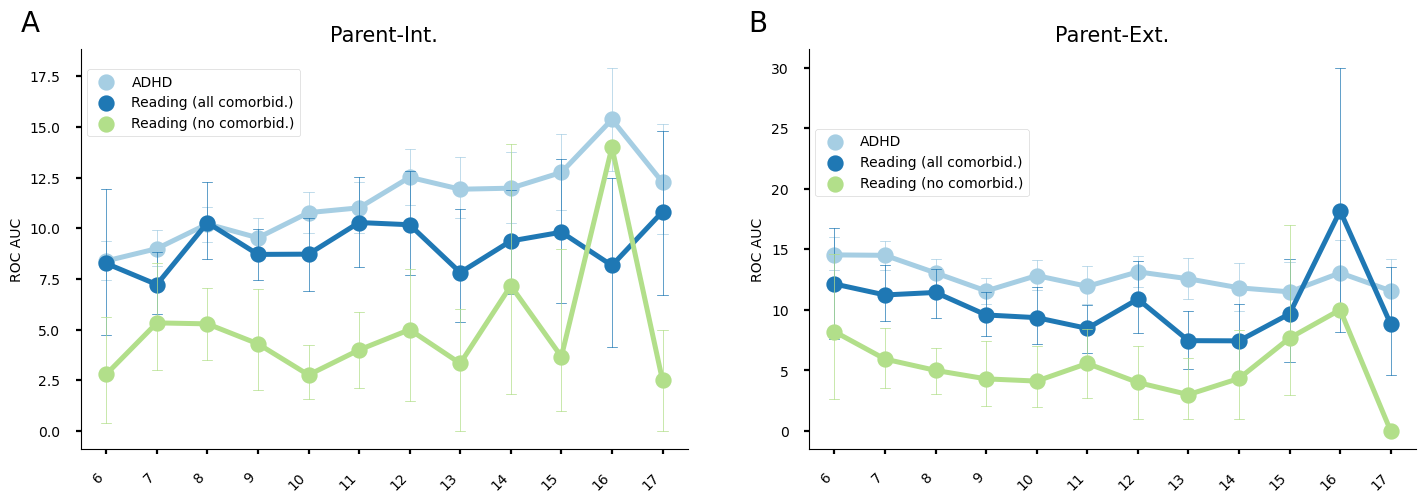

In [190]:
df = raw_scores.load_parent_child_teacher(key=['Int', 'Ext'], dx_to_include=['Reading (all comorbid.)', 'Reading (no comorbid.)', 'ADHD'])

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(2,2))
gs = GridSpec(1, 2, figure=fig)

plot_dict = {'A': ['CBCL,CBCL_Int', (0,0), True, 'Parent-Int.', (.01, .95)],
            'B': ['CBCL,CBCL_Ext', (0,1), True, 'Parent-Ext.', (.01,.8)],
            }

for i, (key, value) in enumerate(plot_dict.items()):
    ax = fig.add_subplot(gs[plot_dict[key][1]])
    vis.pointplot(x='Age_round', y=value[0], hue='DX_Reading', 
                    data=df, ax=ax, ylim=None, subplot=key, 
                    bbox_to_anchor=value[4],
                    title=value[3], legend=value[2])
    
fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'Supp3.png'), bbox_inches='tight')


### Supp 4.

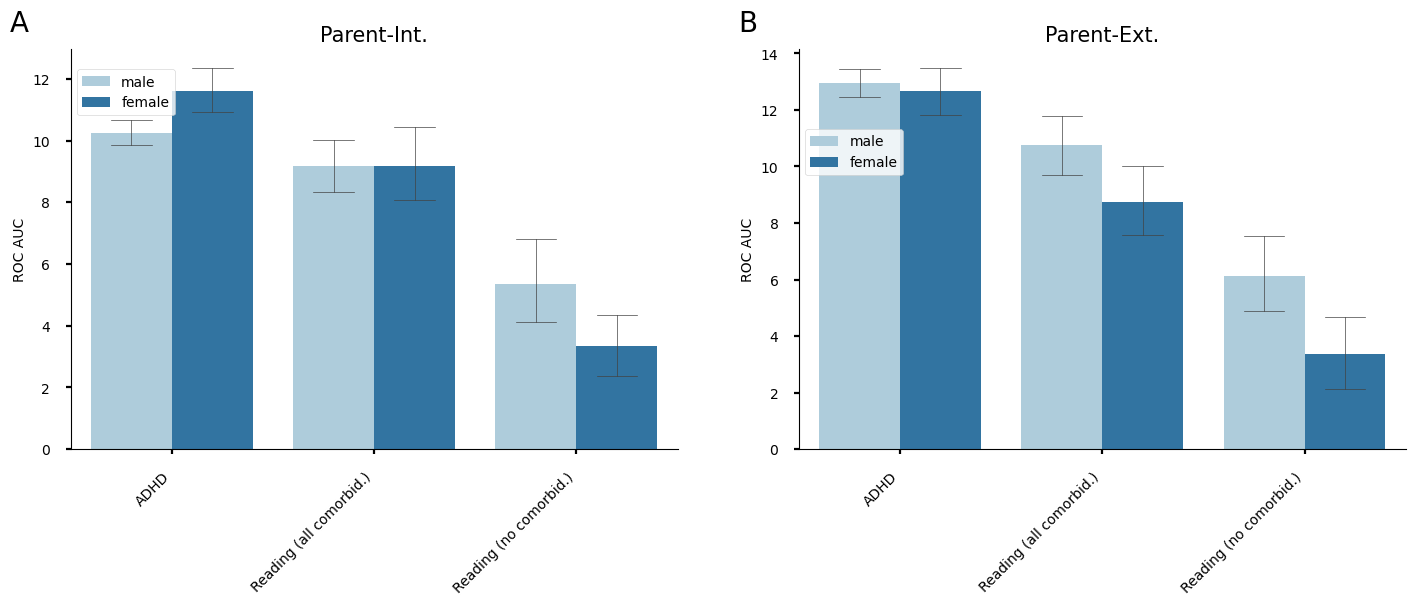

In [191]:
df = raw_scores.load_parent_child_teacher(key=['Int', 'Ext'], dx_to_include=['Reading (all comorbid.)','Reading (no comorbid.)', 'ADHD'])

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(2,2))
gs = GridSpec(1, 2, figure=fig)

plot_dict = {'A': ['CBCL,CBCL_Int', (0,0), True, 'Parent-Int.', (.01, .95)],
            'B': ['CBCL,CBCL_Ext', (0,1), True, 'Parent-Ext.', (.01,.8)],
            }

for i, (key, value) in enumerate(plot_dict.items()):
    ax = fig.add_subplot(gs[plot_dict[key][1]])
    vis.barplot(x='DX_Reading', y=value[0], hue='Sex', 
                    data=df, ax=ax, ylim=None, subplot=key, 
                    bbox_to_anchor=value[4],
                    title=value[3], legend=value[2])
    
fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'Supp4.png'), bbox_inches='tight')


### Supp 4 

ValueError: min() arg is an empty sequence

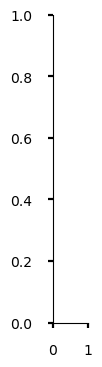

In [38]:
# # plot
vis.plotting_style()
fig = plt.figure(figsize=(1,4))
gs = GridSpec(1, 2, figure=fig)

# 1A
ax = fig.add_subplot(gs[0, 0])

features = ['SES', 'Stress', 'Psychological-Function', 'Family-Function']

default_params = {'Sex': ['male_female'],
                'feature_threshold': ['selected_all', 'top_5_selected_features'],
                'DX': ['reading (all combord.)'],
                'readers': ['all'],
                'data': ['data'],
                'features': features,
                'Race': ['all'],
                }

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

# plot data
vis.barplot(data=df_filter, x='features', hue='feature_threshold', ax=ax)

default_params.update({'data': ['null']})

# filter dataframe to just 1 feature
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

# plot reading model
ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')